In [1]:
import sys
!{sys.executable} -m pip install pandas


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: C:\Users\rajan\mynewenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: C:\Users\rajan\mynewenv\Scripts\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
from datetime import datetime, timedelta

d2 = pd.read_csv('supermarket_sales.csv')
d2

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,03/02/19,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,02/09/19,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


In [2]:
d2.describe()
d2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       1000 non-null   str    
 1   branch           1000 non-null   str    
 2   city             1000 non-null   str    
 3   customer_type    1000 non-null   str    
 4   gender_customer  1000 non-null   str    
 5   product_line     1000 non-null   str    
 6   unit_cost        1000 non-null   float64
 7   quantity         1000 non-null   int64  
 8   5pct_markup      1000 non-null   float64
 9   revenue          1000 non-null   float64
 10  date             1000 non-null   str    
 11  time             1000 non-null   str    
 12  payment_method   1000 non-null   str    
 13  cogs             1000 non-null   float64
 14  gm_pct           1000 non-null   float64
 15  gross_income     1000 non-null   float64
 16  rating           1000 non-null   float64
dtypes: float64(7), int64(1), s

In [3]:
# Convert date
d2["date"] = pd.to_datetime(
    d2["date"],
    format="mixed"
)

# Create combined datetime
d2["datetime"] = pd.to_datetime(
    d2["date"].dt.strftime("%Y-%m-%d") + " " + d2["time"]
)

# Create time features
d2["year"] = d2["datetime"].dt.year
d2["month"] = d2["datetime"].dt.month
d2["day_of_week"] = d2["datetime"].dt.dayofweek
d2["hour"] = d2["datetime"].dt.hour

# Check the result
print(d2[[
    "date",
    "time",
    "datetime",
    "year",
    "month",
    "day_of_week",
    "hour"
]].head())

print("\nData type:")
print(d2["datetime"].dtype)

        date   time            datetime  year  month  day_of_week  hour
0 2019-01-05  13:08 2019-01-05 13:08:00  2019      1            5    13
1 2019-03-08  10:29 2019-03-08 10:29:00  2019      3            4    10
2 2019-03-03  13:23 2019-03-03 13:23:00  2019      3            6    13
3 2019-01-27  20:33 2019-01-27 20:33:00  2019      1            6    20
4 2019-02-08  10:37 2019-02-08 10:37:00  2019      2            4    10

Data type:
datetime64[us]


In [4]:
print("Missing values:")
print(d2.isnull().sum())

print("\nDuplicates:", d2.duplicated().sum())

print("\nShape:", d2.shape)

Missing values:
invoice_id         0
branch             0
city               0
customer_type      0
gender_customer    0
product_line       0
unit_cost          0
quantity           0
5pct_markup        0
revenue            0
date               0
time               0
payment_method     0
cogs               0
gm_pct             0
gross_income       0
rating             0
datetime           0
year               0
month              0
day_of_week        0
hour               0
dtype: int64

Duplicates: 0

Shape: (1000, 22)


In [5]:
model_data_2 = d2.copy()

In [11]:
features_2 = [
    "branch",
    "city",
    "customer_type",
    "gender_customer",
    "product_line",
    "payment_method",
    "unit_cost",
    "rating",
    "month",
    "day_of_week",
    "hour"
]

X2 = model_data_2[features_2]
y2 = model_data_2["quantity"]

print("Features shape:", X2.shape)
print("Target shape:", y2.shape)

Features shape: (1000, 11)
Target shape: (1000,)


In [12]:
print("Quantity statistics:")
print(y2.describe())

Quantity statistics:
count    1000.000000
mean        5.510000
std         2.923431
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: quantity, dtype: float64


In [13]:
print("\nQuantity distribution:")
print(y2.value_counts().sort_index())


Quantity distribution:
quantity
1     112
2      91
3      90
4     109
5     102
6      98
7     102
8      85
9      92
10    119
Name: count, dtype: int64


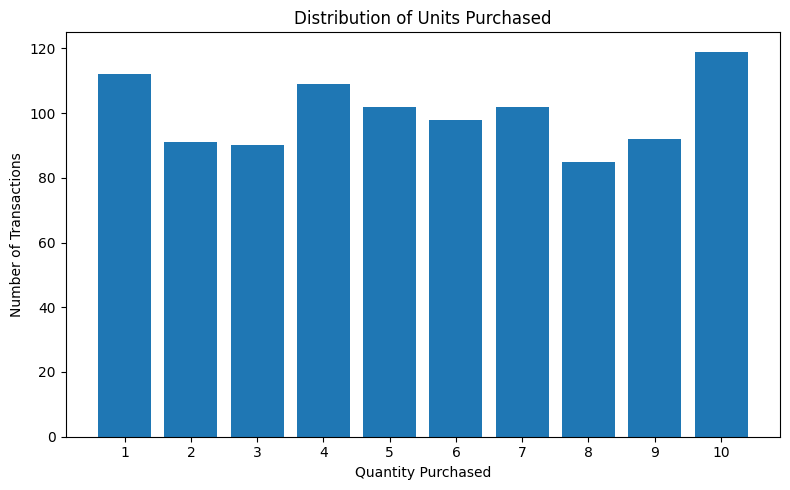

In [9]:
import matplotlib.pyplot as plt

quantity_counts = y2.value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    quantity_counts.index.astype(str),
    quantity_counts.values
)

plt.title("Distribution of Units Purchased")
plt.xlabel("Quantity Purchased")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [ ]:
avg_quantity_product = (
    d2.groupby("product_line")["quantity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    avg_quantity_product.index,
    avg_quantity_product.values
)

plt.title("Average Quantity Purchased by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
avg_quantity_customer = (
    d2.groupby("customer_type")["quantity"]
    .mean()
)

plt.figure(figsize=(7, 5))

plt.bar(
    avg_quantity_customer.index,
    avg_quantity_customer.values
)

plt.title("Average Quantity Purchased by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Quantity")
plt.tight_layout()
plt.show()

In [26]:
d2["high_quantity"] = (
    d2["quantity"] >= 6
).astype(int)

print(d2["high_quantity"].value_counts())

print("\nPercentages:")
print(
    d2["high_quantity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

high_quantity
0    504
1    496
Name: count, dtype: int64

Percentages:
high_quantity
0    50.4
1    49.6
Name: proportion, dtype: float64


In [27]:
features_2 = [
    "branch",
    "city",
    "customer_type",
    "gender_customer",
    "product_line",
    "payment_method",
    "unit_cost",
    "rating",
    "month",
    "day_of_week",
    "hour"
]

In [28]:
X2 = d2[features_2]
y2 = d2["high_quantity"]

print("Features:", X2.shape)
print("Target:", y2.shape)

Features: (1000, 11)
Target: (1000,)


In [29]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

print("Training set:", X2_train.shape)
print("Testing set:", X2_test.shape)

print("\nTraining target distribution:")
print(y2_train.value_counts())

print("\nTesting target distribution:")
print(y2_test.value_counts())

Training set: (800, 11)
Testing set: (200, 11)

Training target distribution:
high_quantity
0    403
1    397
Name: count, dtype: int64

Testing target distribution:
high_quantity
0    101
1     99
Name: count, dtype: int64


In [38]:
categorical_features = [
    "branch",
    "city",
    "customer_type",
    "gender_customer",
    "product_line",
    "payment_method"
]

numerical_features = [
    "unit_cost",
    "rating",
    "month",
    "day_of_week",
    "hour"
]

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [41]:
rf_classifier_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_classifier)
    ]
)

In [42]:
rf_classifier_pipeline.fit(
    X2_train,
    y2_train
)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [43]:
y2_pred = rf_classifier_pipeline.predict(X2_test)

print(y2_pred[:20])

[0 1 1 1 0 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0]


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_2 = accuracy_score(y2_test, y2_pred)
precision_2 = precision_score(y2_test, y2_pred)
recall_2 = recall_score(y2_test, y2_pred)
f1_2 = f1_score(y2_test, y2_pred)

print("Accuracy :", round(accuracy_2, 4))
print("Precision:", round(precision_2, 4))
print("Recall   :", round(recall_2, 4))
print("F1-score :", round(f1_2, 4))

Accuracy : 0.5
Precision: 0.4949
Recall   : 0.4949
F1-score : 0.4949


In [45]:
print("Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred))

print("\nClassification Report:")
print(
    classification_report(
        y2_test,
        y2_pred,
        target_names=["Low quantity", "High quantity"]
    )
)

Confusion Matrix:
[[51 50]
 [50 49]]

Classification Report:
               precision    recall  f1-score   support

 Low quantity       0.50      0.50      0.50       101
High quantity       0.49      0.49      0.49        99

     accuracy                           0.50       200
    macro avg       0.50      0.50      0.50       200
 weighted avg       0.50      0.50      0.50       200



In [46]:
baseline_accuracy_2 = y2_train.value_counts(
    normalize=True
).max()

print(
    "Baseline accuracy:",
    round(baseline_accuracy_2, 4)
)

print(
    "Random Forest accuracy:",
    round(accuracy_2, 4)
)

print(
    "Improvement:",
    round(
        accuracy_2 - baseline_accuracy_2,
        4
    )
)

Baseline accuracy: 0.5038
Random Forest accuracy: 0.5
Improvement: -0.0038


In [47]:
# Get feature names after one-hot encoding
feature_names = (
    rf_classifier_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance
importances = (
    rf_classifier_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance_2 = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_2 = feature_importance_2.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance_2.head(15))

                                             Feature  Importance
19                              numerical__unit_cost    0.185581
20                                 numerical__rating    0.165501
23                                   numerical__hour    0.126246
22                            numerical__day_of_week    0.098386
21                                  numerical__month    0.057495
18               categorical__payment_method_Ewallet    0.025003
16                  categorical__payment_method_Cash    0.024694
7                  categorical__customer_type_Normal    0.024424
17           categorical__payment_method_Credit card    0.023988
8                categorical__gender_customer_Female    0.023438
6                  categorical__customer_type_Member    0.023402
12      categorical__product_line_Food and beverages    0.022510
9                  categorical__gender_customer_Male    0.021711
14      categorical__product_line_Home and lifestyle    0.020973
10  categorical__product_

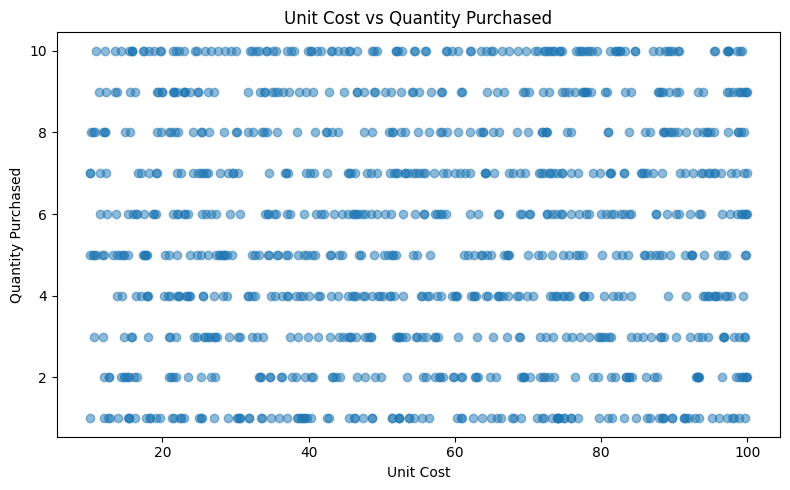

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(
    d2["unit_cost"],
    d2["quantity"],
    alpha=0.5
)

plt.title("Unit Cost vs Quantity Purchased")
plt.xlabel("Unit Cost")
plt.ylabel("Quantity Purchased")

plt.tight_layout()
plt.show()